## Bayesian Modelling of Extreme Flows According for Physical-Geographic Features in Vistula Basin

Paweł Jerzyna, Piotr Grzyb

In [15]:
import os
import sys
import glob
import re
from pathlib import Path
import folium

from cmdstanpy import CmdStanModel

import arviz as az
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path(os.getcwd())
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

DATASET_DIR = PROJECT_ROOT / "dataset"
DATASET_DIR_CLEAN = PROJECT_ROOT / "cleaned_dataset"
DATASET_DIR_TXT = DATASET_DIR_CLEAN / "txt_files"
DATASET_DIR_CSV = DATASET_DIR_CLEAN / "csv_files"

sys.path.append(str(PROJECT_ROOT))




# No module named 'nbfomrmat' error - fix this later
#from utils.notebook import run_notebook
#from utils.display import display_df, display_image
"""
ten folder utils jest podjerzany (stworzony przez czat)
jak chcestawiac docker, to chociaz aby byl on dobzre zrobiony, a nie taki byle jaki
"""

'\nten folder utils jest podjerzany (stworzony przez czat)\njak chcestawiac docker, to chociaz aby byl on dobzre zrobiony, a nie taki byle jaki\n'

## Czyszczenie danych: Ekstrakcja lat 2023-2025 z surowego datasetu do folderu dataset_cleaned

In [16]:
def clean_grdc_file(file_path, output_path):
    metadata = {
        "River": "Nieznana",
        "Station": "Nieznana",
        "Country": "Nieznany",
        "Latitude": "-999.000",
        "Longitude": "-999.000",
        "Catchment": "-999.00",
        "Altitude": "-999.00"
    }
    
    data_lines = []
    
    # Odczyt w kodowaniu 'latin-1' chroni przed błędem crashowania na jednostkach typu km²
    with open(file_path, 'r', encoding='latin-1') as f:
        lines = f.readlines()
        
    for i, line in enumerate(lines):
        stripped = line.strip()
        
        # Przetwarzanie linii nagłówkowych
        if stripped.startswith('#'):
            content = stripped[1:].strip()
            
            if "River:" in content:
                metadata["River"] = content.split("River:")[1].strip()
            elif "Station:" in content:
                metadata["Station"] = content.split("Station:")[1].strip()
            elif "Country:" in content:
                metadata["Country"] = content.split("Country:")[1].strip()
            elif "Latitude (DD):" in content:
                metadata["Latitude"] = content.split("Latitude (DD):")[1].strip()
            elif "Longitude (DD):" in content:
                metadata["Longitude"] = content.split("Longitude (DD):")[1].strip()
            elif "Catchment area" in content:
                val = content.split(":")[-1].strip()
                if not val and i + 1 < len(lines):
                    next_line = lines[i+1].strip()
                    if next_line.startswith('#'):
                        next_line = next_line[1:].strip()
                    if next_line and ';' not in next_line:
                        val = next_line
                metadata["Catchment"] = val if val else "-999.00"
            elif "Altitude (m ASL):" in content:
                metadata["Altitude"] = content.split("Altitude (m ASL):")[1].strip()
                
        # Przetwarzanie linii z pomiarami
        else:
            if ';' in stripped and not stripped.startswith('YYYY'):
                parts = stripped.split(';')
                if parts:
                    date_part = parts[0].strip()
                    try:
                        # Wyciągamy rok i filtrujemy pod kątem lat 2023, 2024, 2025
                        year = int(date_part.split('-')[0])
                        if year in [2023, 2024, 2025]:
                            data_lines.append(line.rstrip())
                    except (ValueError, IndexError):
                        pass

    # Jeśli stacja nie posiada danych z lat 2023-2025, nie generujemy pliku wyjściowego
    if not data_lines:
        return False
    
    # Budowanie struktury pliku tekstowego z zachowaniem idealnego wyrównania spacji
    output_lines = [
        f"River: {metadata['River']}",
        f"Station: {metadata['Station']}",
        f"Country: {metadata['Country']}",
        f"Latitude (DD):       {metadata['Latitude']}",
        f"Longitude (DD):      {metadata['Longitude']}",
        f"Catchment area (km²):      {metadata['Catchment']}",
        f"Altitude (m ASL):        {metadata['Altitude']}",
        "" # Pusta linia oddzielająca metadane od danych
    ]
    
    output_lines.extend(data_lines)
    
    # Zapis w bezpiecznym standardzie UTF-8
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(output_lines) + '\n')
        
    return True

# SZTYWNE USTAWIENIE ŚCIEŻEK - ODPORNE NA CONFIG Z INNYCH KOMÓREK
input_folder = PROJECT_ROOT / "dataset"
output_folder = PROJECT_ROOT / "dataset_cleaned"

if not input_folder.exists():
    print(f"❌ Błąd: Folder źródłowy '{input_folder}' nie istnieje!")
else:
    # Tworzenie nowego folderu docelowego
    output_folder.mkdir(parents=True, exist_ok=True)
        
    # Pobranie wszystkich plików pomijając pliki geojson lub inne śmieciowe
    all_files = [f for f in input_folder.glob('*') if f.is_file() and f.suffix != '.geojson']
    
    print(f"🚀 Rozpoczynam przetwarzanie... Znaleziono {len(all_files)} plików w folderze '{input_folder.name}'.")
    
    success = 0
    skipped = 0
    
    for file_path in all_files:
        # Zapis pod dokładnie taką samą nazwą pliku w nowym katalogu
        output_path = output_folder / file_path.name
        
        try:
            was_written = clean_grdc_file(file_path, output_path)
            if was_written:
                success += 1
            else:
                skipped += 1
        except Exception as e:
            print(f" -> Błąd w pliku {file_path.name}: {str(e)}")
            
    print("\n" + "="*50)
    print(f"✅ Sukces! Oczyszczono i zapisano: {success} plików.")
    print(f"ℹ️ Pominięto starych stacji:       {skipped} plików.")
    print(f"📁 Wyniki znajdziesz w folderze:    '{output_folder}'")
    print("="*50)

🚀 Rozpoczynam przetwarzanie... Znaleziono 85 plików w folderze 'dataset'.

✅ Sukces! Oczyszczono i zapisano: 69 plików.
ℹ️ Pominięto starych stacji:       16 plików.
📁 Wyniki znajdziesz w folderze:    '/home/pawsooon/Documents/Vsc/DA_project/dataset_cleaned'


## Czyszczenie danych: Krok 2 – Konwersja wyekstrahowanych plików TXT do płaskich tabel CSV (Oryginalne nazwy)

In [17]:
# Sztywne ustawienie ścieżek wejścia i wyjścia – niezależne od innych komórek
input_folder = PROJECT_ROOT / "dataset_cleaned"
output_folder = PROJECT_ROOT / "dataset_cleaned_csv"

if not input_folder.exists():
    print(f"❌ Błąd: Folder źródłowy '{input_folder}' nie istnieje! Upewnij się, że najpierw uruchomiłeś poprzednią komórkę.")
else:
    # Tworzymy nowy folder na pliki CSV
    output_folder.mkdir(parents=True, exist_ok=True)
        
    # Pobranie wszystkich plików tekstowych z folderu wyekstrahowanego
    files = [f for f in input_folder.glob('*') if f.is_file()]
    
    print(f"🚀 Rozpoczynam konwersję {len(files)} wyekstrahowanych plików TXT do formatu CSV...")
    
    success_count = 0
    error_count = 0
    
    for file_path in files:
        # Generujemy nową nazwę pliku z rozszerzeniem .csv (np. 6258250_Q_Day.Cmd.csv)
        csv_name = file_path.stem + '.csv'
        output_csv_path = output_folder / csv_name
        
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
                
            metadata = {}
            data_lines = []
            is_data = False
            
            # 1. Parsowanie struktury nagłówków tekstowych i wyodrębnienie linii danych
            for line in lines:
                if ":" in line and not is_data and ";" not in line:
                    key, val = line.split(":", 1)
                    metadata[key.strip()] = val.strip()
                else:
                    is_data = True
                    if ';' in line:
                        data_lines.append(line)
            
            parsed_rows = []
            
            # 2. Przetwarzanie rekordów i budowanie płaskiej struktury tabeli (metadane w każdym wierszu)
            for d_line in data_lines:
                parts = d_line.split(';')
                if len(parts) >= 3:
                    date = parts[0].strip()
                    time = parts[1].strip()
                    value = parts[2].strip()
                    
                    parsed_rows.append({
                        "River": metadata.get("River", "Nieznana"),
                        "Station": metadata.get("Station", "Nieznana"),
                        "Country": metadata.get("Country", "Nieznany"),
                        "Latitude_DD": metadata.get("Latitude (DD)", "-999.000"),
                        "Longitude_DD": metadata.get("Longitude (DD)", "-999.000"),
                        "Catchment_area_km2": metadata.get("Catchment area (km²)", "-999.00"),
                        "Altitude_m_ASL": metadata.get("Altitude (m ASL)", "-999.00"),
                        "Date": date,
                        "Time": time,
                        "Value": value
                    })
            
            # Zapisujemy do CSV – dane są już przefiltrowane, więc bierzemy cały wyekstrahowany pakiet
            if parsed_rows:
                df = pd.DataFrame(parsed_rows)
                df.to_csv(output_csv_path, index=False, encoding='utf-8-sig')
                success_count += 1
                
        except Exception as e:
            print(f" -> Błąd podczas konwersji pliku {file_path.name}: {str(e)}")
            error_count += 1

    # Końcowy raport operacji
    print("\n" + "="*50)
    print("📊 PODSUMOWANIE GENEROWANIA PLIKÓW CSV:")
    print(f"   • Konwersja udana (utworzono plików CSV): {success_count}")
    print(f"   • Błędy przetwarzania:                    {error_count}")
    print(f"📁 Wszystkie wygenerowane pliki znajdziesz w folderze: '{output_folder}'")
    print("="*50)

🚀 Rozpoczynam konwersję 69 wyekstrahowanych plików TXT do formatu CSV...

📊 PODSUMOWANIE GENEROWANIA PLIKÓW CSV:
   • Konwersja udana (utworzono plików CSV): 69
   • Błędy przetwarzania:                    0
📁 Wszystkie wygenerowane pliki znajdziesz w folderze: '/home/pawsooon/Documents/Vsc/DA_project/dataset_cleaned_csv'


## Czyszczenie danych: Krok 3 – Zmiana nazw plików CSV w miejscu (STACJA_RZEKA.csv)

In [18]:
def sanitize_filename(name):
    """Funkcja zamieniająca spacje na myślniki i usuwająca znaki niedozwolone w nazwach plików"""
    if not name or pd.isna(name):
        return "UNKNOWN"
    name = str(name).strip().replace(' ', '-')
    name = re.sub(r'[\\/*?:"<>|]', '', name)
    return name.upper()

# Sztywne ustawienie folderu docelowego - dokładnie tego, który powstał w Kroku 2
target_folder = PROJECT_ROOT / "dataset_cleaned_csv"

if not target_folder.exists():
    print(f"❌ Błąd: Folder z plikami CSV '{target_folder}' nie istnieje! Upewnij się, że poprzednia komórka wykonała się poprawnie.")
else:
    # Zczytujemy listę plików do pamięci jako listę obiektów Path, 
    # aby zmiana nazw w locie nie zaburzyła działania pętli (.glob)
    csv_files = [f for f in target_folder.glob('*.csv') if f.is_file()]
    
    print(f"🔄 Rozpoczynam zmianę nazw dla {len(csv_files)} plików CSV w folderze '{target_folder.name}'...")
    
    renamed_count = 0
    already_correct_count = 0
    skipped_count = 0
    error_count = 0
    
    for file_path in csv_files:
        try:
            # Czytamy tylko pierwszy wiersz pliku CSV, żeby wyciągnąć metadane (szybkie i oszczędne)
            df_head = pd.read_csv(file_path, nrows=1)
            
            if df_head.empty or 'Station' not in df_head.columns or 'River' not in df_head.columns:
                print(f"⚠️ Pomijam {file_path.name} - brak wymaganych kolumn 'Station' lub 'River'.")
                skipped_count += 1
                continue
            
            # Wyciągamy wartości z pierwszego wiersza
            station_raw = df_head['Station'].iloc[0]
            river_raw = df_head['River'].iloc[0]
            
            # Czyszczenie nazw stacji i rzek
            station_clean = sanitize_filename(station_raw)
            river_clean = sanitize_filename(river_raw)
            
            # Budujemy nową nazwę pliku
            new_name = f"{station_clean}_{river_clean}.csv"
            new_path = target_folder / new_name
            
            # Jeśli nazwa różni się od obecnej, zmieniamy ją fizycznie na dysku
            if file_path != new_path:
                # Zabezpieczenie: jeśli plik o takiej nazwie docelowej już istnieje, usuwamy go przed nadpisaniem
                if new_path.exists():
                    os.remove(new_path)
                
                # Zmiana nazwy w miejscu
                file_path.rename(new_path)
                print(f"✅ Zmieniono: {file_path.name} ➡️ {new_name}")
                renamed_count += 1
            else:
                already_correct_count += 1
                
        except Exception as e:
            print(f"❌ Błąd podczas przetwarzania {file_path.name}: {str(e)}")
            error_count += 1

    print("\n" + "="*50)
    print("📊 PODSUMOWANIE ZMIANY NAZW IN-PLACE:")
    print(f"   • Zmieniono nazw plików:         {renamed_count}")
    print(f"   • Pliki już poprawnie nazwane:   {already_correct_count}")
    print(f"   • Pominięto (błędna struktura):  {skipped_count}")
    print(f"   • Błędy wykonania:               {error_count}")
    print(f"📁 Wszystkie zaktualizowane pliki są w: '{target_folder}'")
    print("="*50)

🔄 Rozpoczynam zmianę nazw dla 138 plików CSV w folderze 'dataset_cleaned_csv'...
✅ Zmieniono: 6458090_Q_Day.Cmd.csv ➡️ PULAWY-AZOTY_VISTULA.csv
✅ Zmieniono: 6458130_Q_Day.Cmd.csv ➡️ WARSZAWA-NADWILANOWKA_VISTULA.csv
✅ Zmieniono: 6458420_Q_Day.Cmd.csv ➡️ WISLA_VISTULA.csv
✅ Zmieniono: 6458135_Q_Day.Cmd.csv ➡️ ZAMBSKI-KOSCIELNE_NAREV.csv
✅ Zmieniono: 6458030_Q_Day.Cmd.csv ➡️ JELEN_PRZEMSZA.csv
✅ Zmieniono: 6458025_Q_Day.Cmd.csv ➡️ PRZEMYSL_SAN.csv
✅ Zmieniono: 6458200_Q_Day.Cmd.csv ➡️ JORDANOW_SKAWA.csv
✅ Zmieniono: 6458525_Q_Day.Cmd.csv ➡️ NIETULISKO-DUZE_SWISLINA.csv
✅ Zmieniono: 6458809_Q_Day.Cmd.csv ➡️ MYSZYNIEC_ROZOGA.csv
✅ Zmieniono: 6458165_Q_Day.Cmd.csv ➡️ STREKOWA-GORA_NAREV.csv
✅ Zmieniono: 6458020_Q_Day.Cmd.csv ➡️ STARY-SACZ_POPRAD.csv
✅ Zmieniono: 6458620_Q_Day.Cmd.csv ➡️ CISNA_SOLINKA.csv
✅ Zmieniono: 6458120_Q_Day.Cmd.csv ➡️ MODLIN_VISTULA.csv
✅ Zmieniono: 6458150_Q_Day.Cmd.csv ➡️ DOBRYLAS_PISA.csv
✅ Zmieniono: 6458055_Q_Day.Cmd.csv ➡️ MIELEC-2_WISLOKA.csv
✅ Zmieniono: 6458

## Wizualizacja stacji: Punkty pomiarowe na mapie Polski

In [19]:
csv_folder = PROJECT_ROOT / "RANDOMOWE COS NARAZIE ABY SIE NIE WYSWIETLALA MAPKA"

if not csv_folder.exists():
    print("❌ Błąd: Folder z plikami CSV nie istnieje!")
else:
    csv_files = list(csv_folder.glob('*.csv'))
    
    # Tworzymy bazową mapę wyśrodkowaną na Polskę
    # tiles='OpenStreetMap' pobiera kafelki mapy automatycznie z sieci
    m = folium.Map(location=[52.0, 19.1], zoom_start=6, tiles='OpenStreetMap')
    
    counter = 0
    for file_path in csv_files:
        try:
            df_head = pd.read_csv(file_path, nrows=1)
            lat = float(df_head['Latitude_DD'].iloc[0])
            lon = float(df_head['Longitude_DD'].iloc[0])
            station = df_head['Station'].iloc[0]
            river = df_head['River'].iloc[0]
            country = df_head['Country'].iloc[0]
            
            if lat != -999.000 and lon != -999.000:
                # Treść dymka po kliknięciu w punkt
                popup_text = f"<b>Stacja:</b> {station}<br><b>Rzeka:</b> {river}<br><b>Kraj:</b> {country}"
                
                # Dodajemy punkt na mapę
                folium.Marker(
                    location=[lat, lon],
                    popup=folium.Popup(popup_text, max_width=300),
                    tooltip=f"{station} ({river})",
                    icon=folium.Icon(color='blue', icon='info-sign')
                ).add_to(m)
                
                counter += 1
        except Exception as e:
            pass

    print(f"📊 Załadowano {counter} stacji. Wyświetlam interaktywną mapę...")
    # Wyświetlenie mapy bezpośrednio w Jupyter Notebook
    
    # NAPRAWIC !!!
    display(m)

    # Zapisuje mapę jako autonomiczny plik HTML w Twoim folderze projektu
    m.save("mapa_stacji.html")
    print("🌍 Mapa została zapisana! Otwórz plik 'mapa_stacji.html' bezpośrednio w przeglądarce (Chrome/Firefox).")


❌ Błąd: Folder z plikami CSV nie istnieje!


# Konkatenacja wyczyszczonych danych w dataframe i filtrowanie

In [23]:
# Define directory containing CSV files
csv_folder = Path("dataset_cleaned_csv") 

# Initialize empty list to store dataframes
df_list = []

# Iterate through all CSV files
for file_path in csv_folder.glob("*.csv"):
    temp_df = pd.read_csv(file_path)
    
    # Format dates and handle missing values
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    temp_df['Value'] = temp_df['Value'].replace(-999.000, pd.NA)
    
    df_list.append(temp_df)

# Concatenate into a single long-format dataframe
df = pd.concat(df_list, ignore_index=True)

# Remove rows with missing flow values
df = df.dropna(subset=['Value'])

# Verify structure
print(df.info())

<class 'pandas.DataFrame'>
Index: 52855 entries, 0 to 52860
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   River               52855 non-null  str           
 1   Station             52855 non-null  str           
 2   Country             52855 non-null  str           
 3   Latitude_DD         52855 non-null  float64       
 4   Longitude_DD        52855 non-null  float64       
 5   Catchment_area_km2  52855 non-null  float64       
 6   Altitude_m_ASL      52855 non-null  float64       
 7   Date                52855 non-null  datetime64[us]
 8   Time                52855 non-null  str           
 9   Value               52855 non-null  object        
dtypes: datetime64[us](1), float64(4), object(1), str(4)
memory usage: 4.4+ MB
None


In [27]:
# Filter out non-positive values
df['Value'] = df['Value'].replace(0.0, 1e-1)
df = df.dropna(subset=['Value'])

# Map station names to consecutive integers (1 to S)
unique_stations = df['Station'].unique()
station_to_id = {name: idx + 1 for idx, name in enumerate(unique_stations)}
df['station_id'] = df['Station'].map(station_to_id)

# Create data dictionary for Stan
stan_data = {
    'N': len(df),
    'S': len(unique_stations),
    'station_id': df['station_id'].values,
    'y': df['Value'].values
}

# Podstawowy Model 

Cel modelu: Estymacja i symulacja przepływów rzek ($Q$) w wybranych stacjach pomiarowych przy użyciu wnioskowania bayesowskiego. Model bazowy implementuje płaską, dwupoziomową strukturę hierarchiczną, w której parametry poszczególnych stacji są powiązane wspólnym, globalnym trendem dla całego kraju.

## 1. Zmienne i Przygotowanie Danych

Model operuje na zestawie danych ciągłych reprezentujących dzienne pomiary ze stacji hydrologicznych. Ze względu na specyfikę transformacji logarytmicznej, dane wejściowe poddano procesowi filtracji: wartości całkowicie zerowe (spowodowane np. zamarznięciem koryta lub awarią czujnika) zostały zastąpione bezpieczną wartością zastępczą $0.1 \text{ m}^3/\text{s}$. Zapobiega to powstawaniu asymptotycznych błędów matematycznych (logarytm z zera dążący do minus nieskończoności) w trakcie samplowania.

* **$N$** – Całkowita liczba obserwacji (pomiarów) w zbiorze.
* **$S$** – Liczba unikalnych stacji pomiarowych.
* **$y$** – Zaobserwowany przepływ w rzece [$\text{m}^3/\text{s}$].
* **$\text{station\_id}$** – Wektor indeksów przypisujący każdą obserwację $y_n$ do konkretnej stacji $s \in \{1, \dots, S\}$.

## 2. Architektura Matematyczna

Biorąc pod uwagę prawoskośną naturę hydrologii (gdzie większość dni charakteryzuje się niskim, bazowym przepływem, a powodzie stanowią ekstremalne, rzadkie odchylenia), w modelu zastosowano rozkład log-normalny.

Aby ułatwić działanie algorytmu MCMC (Hamiltonian Monte Carlo) i zapobiec problemom z trudną geometrią przestrzeni prawdopodobieństwa (divergent transitions), wdrożono parametryzację niescentrowaną (non-centered parameterization). Dodatkowo, skala wariancji jest modelowana w przestrzeni logarytmicznej, co po nałożeniu funkcji wykładniczej (exp) matematycznie gwarantuje, że odchylenie standardowe będzie zawsze dodatnie.

### Równania modelu:

1. **Funkcja Wiarygodności (Likelihood):**
   $$y_n \sim \text{LogNormal}(\mu_{s[n]}, \sigma_{s[n]})$$

2. **Poziom Stacji (Transformacja niescentrowana):**
   $$\mu_s = \mu_{\text{global}} + \tau_{\mu} \cdot \mu_{\text{raw}, s}$$
   $$\sigma_s = \exp(\log(\sigma_{\text{global}}) + \tau_{\sigma} \cdot \sigma_{\text{raw}, s})$$

3. **Zmienne pomocnicze przestrzeni standaryzowanej:**
   $$\mu_{\text{raw}, s} \sim \mathcal{N}(0, 1)$$
   $$\sigma_{\text{raw}, s} \sim \mathcal{N}(0, 1)$$

## 3. Zaktualizowane Rozkłady a priori, kalibracja PPC i Prior Predictive Check

Początkowe, słabo informatywne założenia zostały poddane rygorystycznej kalibracji za pomocą testów Prior Predictive Checks (PPC). Celem optymalizacji było znalezienie balansu między stabilnością obliczeniową a wiernością fizyczną.

Hiperparametry zostały dostrojone tak, aby obciąć niefizyczny ogon rozkładu (generujący niemożliwe przepływy rzędu milionów metrów sześciennych na sekundę), zachowując jednocześnie odpowiedni margines swobody. Ostateczne wartości dają modelowi matematyczny margines, pozwalając 99. percentylowi predykcji a priori osiągać bezpieczny, ale realistyczny pułap wokół $5000 \text{ m}^3/\text{s}$, co umożliwia algorytmowi naukę i rozpoznawanie historycznych powodzi na największych rzekach.

| Parametr | Rozkład | Uzasadnienie fizyczne |
| :--- | :--- | :--- |
| **$\mu_{\text{global}}$** | $\mathcal{N}(3, 1.2)$ | Globalna średnia przepływów w skali logarytmicznej. Odchylenie $1.2$ pozwala modelowi rozważać zarówno małe strumienie, jak i potężne rzeki u ujścia. |
| **$\tau_{\mu}$** | $\text{Half-}\mathcal{N}(0, 1.2)$ | Tolerancja na odchylenia globalnej średniej (zmienność między stacjami). Rozszerzona, by objąć różnice hydrologiczne Polski. |
| **$\log(\sigma_{\text{global}})$** | $\mathcal{N}(0, 0.5)$ | Baza dla odchylenia standardowego szumu pomiarowego. Wąskie odchylenie $0.5$ zapobiega eksplozji prawego ogona rozkładu log-normalnego. |
| **$\tau_{\sigma}$** | $\text{Half-}\mathcal{N}(0, 0.5)$ | Zmienność rozrzutu dynamiki wody (wariancji) pomiędzy poszczególnymi stacjami. |

Wiedza dziedzinowa to że rzeka w Polsce nie może płynąć wstecz (przepływ <0) ani nie może nagle osiągnąć wartości 10^22 $\text{m}^3/\text{s}$. Na podstawie tych założeń oraz naszych kilku prób intuicyjnego doboru wartości do rozkładu, zostaliśmy z tymi powyżej.

19:47:03 - cmdstanpy - INFO - CmdStan start processing
19:47:03 - cmdstanpy - INFO - Chain [1] start processing


Uruchamianie Prior Predictive Check...


19:47:15 - cmdstanpy - INFO - Chain [1] done processing


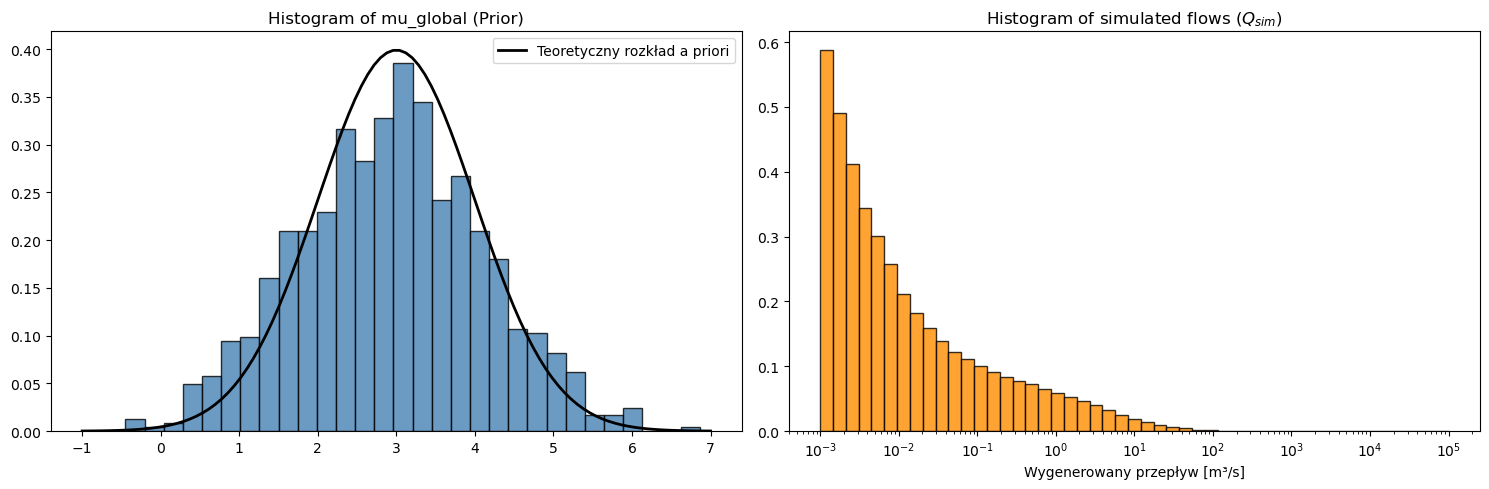

In [28]:
# Kompilacja modelu prior (upewnij się, że plik nazywa się model_lognormal_base_prior.stan)
model_prior = CmdStanModel(stan_file="stan/model_lognormal_base_prior.stan")

print("Uruchamianie Prior Predictive Check...")
sim_prior = model_prior.sample(
    data=stan_data,
    iter_sampling=1000,
    iter_warmup=1,
    chains=1,
    fixed_param=True,
    seed=42,
    show_progress=False
)

mu_global_pred = sim_prior.stan_variable("mu_global")
y_sim_raw = sim_prior.stan_variable("y_sim").flatten()

# Obcięcie wartości subatomowych i gigantycznych powodzi
y_visual = y_sim_raw[(y_sim_raw > 1e-3) & (y_sim_raw < 1e5)] 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=100)

# Wykres 1
x_mu = np.linspace(-1, 7, 100)
y_mu = stats.norm.pdf(x_mu, loc=3, scale=1) # mu_global ~ normal(3, 1)
ax1.hist(mu_global_pred, bins=30, density=True, alpha=0.8, edgecolor='black', color='steelblue')
ax1.plot(x_mu, y_mu, color='k', linewidth=2, label='Teoretyczny rozkład a priori')
ax1.set_title(r'Histogram of mu_global (Prior)', fontsize=12)
ax1.legend()

# Wykres 2
bins_safe = np.logspace(np.log10(min(y_visual)), np.log10(max(y_visual)), 50)
ax2.hist(y_visual, bins=bins_safe, density=True, alpha=0.8, edgecolor='black', color='darkorange')
ax2.set_xscale('log')
ax2.set_title(r'Histogram of simulated flows ($Q_{sim}$)', fontsize=12)
ax2.set_xlabel('Wygenerowany przepływ [m³/s]')

plt.tight_layout()
plt.show()

In [ ]:
# Szybki raport fizyczny z symulacji a priori
print("\n" + "="*50)
print("📊 RAPORT PRIOR PREDICTIVE CHECK:")
print(f"   • Mediana wygenerowanych przepływów: {np.median(y_visual):.2f} m³/s")
print(f"   • 95. percentyl przepływu w PPC:     {np.percentile(y_visual, 95):.2f} m³/s")
print(f"   • 99. percentyl (ekstremum):         {np.percentile(y_visual, 99):.2f} m³/s")
print("="*50)


📊 RAPORT PRIOR PREDICTIVE CHECK:
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
   • Mediana wygenerowanych przepływów: 18.73 m³/s
   • 95. percentyl przepływu w PPC:     652.91 m³/s
   • 99. percentyl (ekstremum):         5150.96 m³/s


# Posterior

Uruchomienie Próbkowania A Posteriori (MCMC): Wykonanie właściwego treningu zaktualizowanego modelu na pełnym zbiorze danych dobowych z roku 2023

In [ ]:
# ====================================================================
# PRZYGOTOWANIE DANYCH I URUCHOMIENIE TRENINGU MODELU BAZOWEGO
# ====================================================================
# 1. Korekta i synchronizacja wartości zerowych (zgodnie z opisem teoretycznym = 0.1 m³/s)
# Chroni przed błędem Prior-Data Conflict, który zawiesiłby działanie HMC
df['Value'] = df['Value'].replace(0.0, 0.1) # ja to juz chyba dodalem wyzej???
df = df.dropna(subset=['Value'])

# 2. Mapowanie nazw stacji na kolejne liczby całkowite od 1 do S
unique_stations = df['Station'].unique()
station_to_id = {name: idx + 1 for idx, name in enumerate(unique_stations)}
df['station_id'] = df['Station'].map(station_to_id)

# 3. Przygotowanie słownika danych – pod nazwą oczekiwaną przez komórkę z posteriorem
stan_data_base = {
    'N': int(len(df)),
    'S': int(len(unique_stations)),
    'station_id': df['station_id'].values.astype(int),
    'y': df['Value'].values.astype(float)
}

print(f"✅ Dane wejściowe przygotowane pomyślnie.")
print(f"   • Liczba dobowych obserwacji (N): {stan_data_base['N']}")
print(f"   • Liczba stacji pomiarowych (S):  {stan_data_base['S']}")

# 4. Definicja ścieżki i kompilacja modelu docelowego
stan_file_path = "stan/model_lognormal_base_pawel.stan"
model_base = CmdStanModel(stan_file=stan_file_path)

print("\n🚀 URUCHAMIAM PRÓBKOWANIE A POSTERIORI (MCMC)...")
# Próbkowanie na 4 niezależnych łańcuchach, każdy po 1000 iteracji warmup i sampling
fit_base = model_base.sample(
    data=stan_data_base,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True
)

# 5. Konwersja wyników do uniwersalnego formatu ArviZ InferenceData
idata_base = az.from_cmdstanpy(
    posterior=fit_base,
    posterior_predictive=["y_rep"],
    log_likelihood="log_lik",
    observed_data={"y": stan_data_base['y']}
)

print("\n✅ Trening zakończony sukcesem! Wyniki zapisano w obiekcie 'idata_base'.")

# Wyświetlenie podsumowania zbieżności parametrów globalnych wyższego rzędu
print("\n📊 STATYSTYKI DOPASOWANIA PARAMETRÓW GLOBALNYCH:")
print(az.summary(idata_base, var_names=['mu_global', 'log_sigma_global', 'tau_mu', 'tau_sigma']))

# Rozszerzony (Zagnieżdżony) Model Bayesowski (Nested Model)

Cel modelu: Zaawansowana estymacja i symulacja przepływów rzek ($Q$) z uwzględnieniem trójpoziomowej struktury hierarchicznej. Model rozszerzony wprowadza dodatkową warstwę grupowania – poziom pojedynczych rzek ($R$), co pozwala na wychwycenie korelacji przestrzennych między stacjami pomiarowymi zlokalizowanymi w obrębie tego samego dorzecza bądź cieku wodnego.

## 1. Zmienne i Przygotowanie Danych

Struktura danych opiera się na kaskadowym powiązaniu obserwacji ze stacjami, a stacji z konkretnymi rzekami. Podobnie jak w modelu bazowym, filtracja danych wejściowych obejmuje zastąpienie wartości zerowych wartością bezpieczną $0.1 \text{ m}^3/\text{s}$ w celu stabilizacji numerycznej operacji logarytmowania.

* **$N$** – Całkowita liczba obserwacji (pomiarów) w zbiorze.
* **$S$** – Liczba unikalnych stacji pomiarowych.
* **$R$** – Liczba unikalnych rzek w dorzeczu.
* **$y$** – Zaobserwowany przepływ w rzece [$\text{m}^3/\text{s}$].
* **$\text{station\_id}$** – Wektor przypisujący obserwację $y_n$ do stacji $s \in \{1, \dots, S\}$.
* **$\text{station\_to\_river}$** – Tablica indeksów mapująca każdą stację $s$ na odpowiednią rzekę $r \in \{1, \dots, R\}$.

## 2. Architektura Matematyczna

Model wykorzystuje strukturę log-normalną zagnieżdżoną hierarchicznie (Nested Hierarchical Log-Normal Model). Ze względu na wysoką złożoność obliczeniową i ryzyko wystąpienia tzw. lejka Neala (Neal's Funnel), wdrożono pełną parametryzację niescentrowaną na obu poziomach hierarchii (zarówno rzeki, jak i stacji). 

Skala zmienności (wariancja) dla stacji jest determinowana przez wariancję przypisanej do niej rzeki, która z kolei zależy od średniej globalnej. Transformacja funkcją wykładniczą (exp) realizowana jest na najniższym poziomie, co zapewnia stabilność i dodatniość parametru skali.

### Równania modelu:

1. **Funkcja Wiarygodności (Likelihood):**
   $$y_n \sim \text{LogNormal}(\mu_{s[n]}, \sigma_{s[n]})$$

2. **Poziom Stacji (Zagnieżdżenie w rozkładzie rzeki):**
   $$\mu_s = \mu_{\text{river}[s]} + \tau_{\mu, \text{station}} \cdot \mu_{\text{raw}, s}$$
   $$\sigma_s = \exp(\log(\sigma_{\text{river}[s]}) + \tau_{\sigma, \text{station}} \cdot \sigma_{\text{raw}, s})$$

3. **Poziom Rzeki (Zagnieżdżenie w rozkładzie globalnym):**
   $$\mu_r = \mu_{\text{global}} + \tau_{\mu, \text{river}} \cdot \mu_{\text{river\_raw}, r}$$
   $$\log(\sigma_r) = \log(\sigma_{\text{global}}) + \tau_{\sigma, \text{river}} \cdot \log(\sigma_{\text{river\_raw}, r})$$

4. **Zmienne pomocnicze przestrzeni standaryzowanej:**
   $$\mu_{\text{raw}, s}, \sigma_{\text{raw}, s}, \mu_{\text{river\_raw}, r}, \log(\sigma_{\text{river\_raw}, r}) \sim \mathcal{N}(0, 1)$$

## 3. Rozkłady a priori (Priors) i Konfiguracja Próbkowania

Rozkłady hiperparametrów na poziomie globalnym są w pełni spójne z kalibracją przeprowadzoną w teście Prior Predictive Check dla modelu bazowego. Rozkłady dla odchyleń standardowych poszczególnych poziomów ($\tau$) zostały dobrane tak, aby ograniczyć ryzyko przestrzennej eksplozji wariancji.

Wprowadzenie dodatkowego poziomu hierarchii przy jednoczesnym zachowaniu niskich wartości przepływów (0.1) generuje strome gradienty log-prawdopodobieństwa. W związku z tym, proces samplowania MCMC wymaga zaostrzenia parametrów kontrolnych algorytmu: podbicia współczynnika adaptacji (`adapt_delta = 0.99`) oraz maksymalnej głębokości drzewa poszukiwań (`max_treedepth = 15`), co zapobiega powstawaniu błędów rozbieżności.

| Parametr | Rozkład | Zakres i rola w hierarchii |
| :--- | :--- | :--- |
| **$\mu_{\text{global}}$** | $\mathcal{N}(3, 1.2)$ | Średni punkt odniesienia dla logarytmu przepływów w skali kraju. |
| **$\log(\sigma_{\text{global}})$** | $\mathcal{N}(0, 0.5)$ | Centralna wartość bazowa dla skali szumu pomiarowego. |
| **$\tau_{\mu, \text{river}}$** | $\text{Half-}\mathcal{N}(0, 1.2)$ | Zmienność średnich przepływów pomiędzy różnymi rzekami. |
| **$\tau_{\sigma, \text{river}}$** | $\text{Half-}\mathcal{N}(0, 0.5)$ | Zmienność dynamiki i rozrzutu falowości pomiędzy rzekami. |
| **$\tau_{\mu, \text{station}}$** | $\text{Half-}\mathcal{N}(0, 1.2)$ | Lokalna zmienność średnich przepływów stacji w obrębie tej samej rzeki. |
| **$\tau_{\sigma, \text{station}}$** | $\text{Half-}\mathcal{N}(0, 0.5)$ | Lokalna zmienność szumu stacji w ramach jednej rzeki. |m

In [ ]:
# Kompilacja i uruchomienie PPC dla modelu rozszerzonego
model_nested_prior = CmdStanModel(stan_file="stan/model_lognormal_nested_prior.stan")

print("Uruchamianie Prior Predictive Check dla modelu zagnieżdżonego...")
sim_nested_prior = model_nested_prior.sample(
    data=stan_data_nested, # Używa słownika zawierającego N, S, R, station_id oraz station_to_river
    iter_sampling=1000,
    iter_warmup=1,
    chains=1,
    fixed_param=True,
    seed=42,
    show_progress=False
)

# Wyciągnięcie zmiennych do analizy
y_sim_nested = sim_nested_prior.stan_variable("y_sim").flatten()
y_visual_nested = y_sim_nested[(y_sim_nested > 1e-3) & (y_sim_nested < 1e5)]

# Wyświetlenie raportu liczbowego
print("\n" + "="*50)
print("📊 RAPORT PRIOR PREDICTIVE CHECK (Model Zagnieżdżony):")
print(f"   • Mediana wygenerowanych przepływów: {np.median(y_visual_nested):.2f} m³/s")
print(f"   • 95. percentyl przepływu w PPC:     {np.percentile(y_visual_nested, 95):.2f} m³/s")
print(f"   • 99. percentyl (ekstremum):         {np.percentile(y_visual_nested, 99):.2f} m³/s")
print("="*50)

13:24:53 - cmdstanpy - INFO - compiling stan file /workspace/Data-Analytics-Project/stan/model_lognormal_nested_prior.stan to exe file /workspace/Data-Analytics-Project/stan/model_lognormal_nested_prior
13:25:00 - cmdstanpy - INFO - compiled model executable: /workspace/Data-Analytics-Project/stan/model_lognormal_nested_prior
13:25:01 - cmdstanpy - INFO - CmdStan start processing
13:25:01 - cmdstanpy - INFO - Chain [1] start processing


Uruchamianie Prior Predictive Check dla modelu zagnieżdżonego...


13:25:11 - cmdstanpy - INFO - Chain [1] done processing



📊 RAPORT PRIOR PREDICTIVE CHECK (Model Zagnieżdżony):
   • Mediana wygenerowanych przepływów: 19.22 m³/s
   • 95. percentyl przepływu w PPC:     1374.78 m³/s
   • 99. percentyl (ekstremum):         13090.42 m³/s


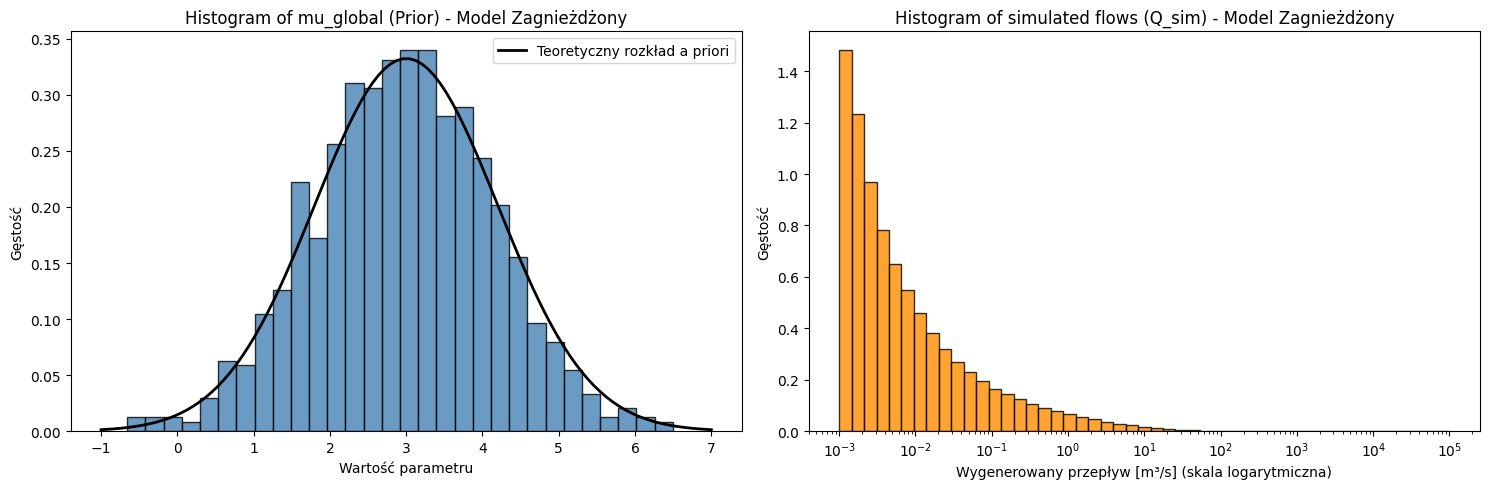

In [ ]:
# Wyciągnięcie zmiennych z obiektu symulacji modelu zagnieżdżonego
mu_global_pred_nested = sim_nested_prior.stan_variable("mu_global")
y_sim_nested = sim_nested_prior.stan_variable("y_sim").flatten()

# Obcięcie skrajnych wartości subatomowych i anomalii dla poprawnego obliczenia bins
y_visual_nested = y_sim_nested[(y_sim_nested > 1e-3) & (y_sim_nested < 1e5)]

# Inicjalizacja przestrzeni wykresów (1 wiersz, 2 kolumny)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=100)

# WYKRES 1: Histogram parametru mu_global (przestrzeń logarytmiczna)
# Generowanie teoretycznej krzywej gęstości normal(3, 1.2) dla porównania
x_mu = np.linspace(-1, 7, 100)
y_mu = stats.norm.pdf(x_mu, loc=3, scale=1.2)

ax1.hist(mu_global_pred_nested, bins=30, density=True, alpha=0.8, edgecolor='black', color='steelblue')
ax1.plot(x_mu, y_mu, color='k', linewidth=2, label='Teoretyczny rozkład a priori')
ax1.set_title('Histogram of mu_global (Prior) - Model Zagnieżdżony', fontsize=12)
ax1.set_xlabel('Wartość parametru')
ax1.set_ylabel('Gęstość')
ax1.legend()

# WYKRES 2: Histogram wygenerowanych przepływów Q_sim (przestrzeń fizyczna)
# Definicja bezpiecznych kroków na osi logarytmicznej
bins_safe = np.logspace(np.log10(min(y_visual_nested)), np.log10(max(y_visual_nested)), 50)

ax2.hist(y_visual_nested, bins=bins_safe, density=True, alpha=0.8, edgecolor='black', color='darkorange')
ax2.set_xscale('log')
ax2.set_title('Histogram of simulated flows (Q_sim) - Model Zagnieżdżony', fontsize=12)
ax2.set_xlabel('Wygenerowany przepływ [m³/s] (skala logarytmiczna)')
ax2.set_ylabel('Gęstość')

plt.tight_layout()
plt.show()

Model podstawowy

In [ ]:
# Szybki raport fizyczny z symulacji a priori
print("\n" + "="*50)
print("📊 RAPORT PRIOR PREDICTIVE CHECK:")
print(f"   • Mediana wygenerowanych przepływów: {np.median(y_visual):.2f} m³/s")
print(f"   • 95. percentyl przepływu w PPC:     {np.percentile(y_visual, 95):.2f} m³/s")
print(f"   • 99. percentyl (ekstremum):         {np.percentile(y_visual, 99):.2f} m³/s")
print("="*50)


📊 RAPORT PRIOR PREDICTIVE CHECK:
   • Mediana wygenerowanych przepływów: 18.73 m³/s
   • 95. percentyl przepływu w PPC:     652.91 m³/s
   • 99. percentyl (ekstremum):         5150.96 m³/s


In [ ]:
# Compile model
stan_file_path = "stan/model_lognormal_base.stan"
model = CmdStanModel(stan_file=stan_file_path)

# Run MCMC sampling
fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True
)

# Convert results to ArviZ InferenceData object
idata = az.from_cmdstanpy(
    posterior=fit,
    posterior_predictive=["y_rep"],
    observed_data={"y": stan_data['y']}
)

00:10:26 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

00:11:16 - cmdstanpy - ERROR - Chain [2] error: terminated by signal 2 Unknown error -2
00:11:16 - cmdstanpy - ERROR - Chain [4] error: terminated by signal 2 Unknown error -2
00:11:16 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 2 Unknown error -2
00:11:16 - cmdstanpy - ERROR - Chain [3] error: terminated by signal 2 Unknown error -2


KeyboardInterrupt: 

In [ ]:
# Kompilacja głównego modelu bazowego
model_base = CmdStanModel(stan_file="stan/model_lognormal_base.stan")

print("Uruchamianie treningu modelu bazowego na danych pomiarowych...")
fit_base = model_base.sample(
    data=stan_data_base,  # Słownik danych wejściowych (N, S, station_id, y)
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True
)

# Konwersja wyników do formatu ArviZ dla łatwiejszej analizy i wykresów PPC
idata_base = az.from_cmdstanpy(
    posterior=fit_base,
    posterior_predictive=["y_rep"],
    observed_data={"y": stan_data_base['y']}
)

# Wyświetlenie podsumowania statystycznego dla parametrów globalnych
print("\nStatystyki dopasowania parametrów globalnych:")
print(az.summary(idata_base, var_names=['mu_global', 'log_sigma_global', 'tau_mu', 'tau_sigma']))

Model rozszerzony

In [ ]:
# Kompilacja modelu zagnieżdżonego
model_nested = CmdStanModel(stan_file="stan/model_lognormal_nested.stan")

print("Uruchamianie treningu modelu zagnieżdżonego (adapt_delta=0.99, max_treedepth=15)...")
fit_nested = model_nested.sample(
    data=stan_data_nested,  # Słownik danych (N, S, R, station_id, station_to_river, y)
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    adapt_delta=0.99,       # Wymuszenie mniejszych kroków w celu obsługi wartości 0.1
    max_treedepth=15,       # Zwiększenie limitu głębokości drzewa poszukiwań
    show_progress=True
)

# Konwersja wyników do formatu ArviZ
idata_nested = az.from_cmdstanpy(
    posterior=fit_nested,
    posterior_predictive=["y_rep"],
    observed_data={"y": stan_data_nested['y']}
)

# Wyświetlenie podsumowania statystycznego parametrów globalnych i zmienności hierarchicznej
print("\nStatystyki dopasowania parametrów modelu zagnieżdżonego:")
print(az.summary(idata_nested, var_names=['mu_global', 'log_sigma_global', 'tau_mu_river', 'tau_mu_station']))